In [4]:
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error
import random
import numpy as np

Завантажуємо MNIST. Ділимо значення пікселів на 255, щоб привести їх до діапазону від 0 до 1

In [5]:
print("Завантажую датасет MNIST...")

X, y = fetch_openml(data_id=554, return_X_y=True, as_frame=False)

print("Форма матриці X:", X.shape)
print("Кількість унікальних міток:", len(np.unique(y)))

Завантажую датасет MNIST...
Форма матриці X: (70000, 784)
Кількість унікальних міток: 10


Малюємо кілька випадкових цифр, щоб переконатися, що дані завантажилися правильно.

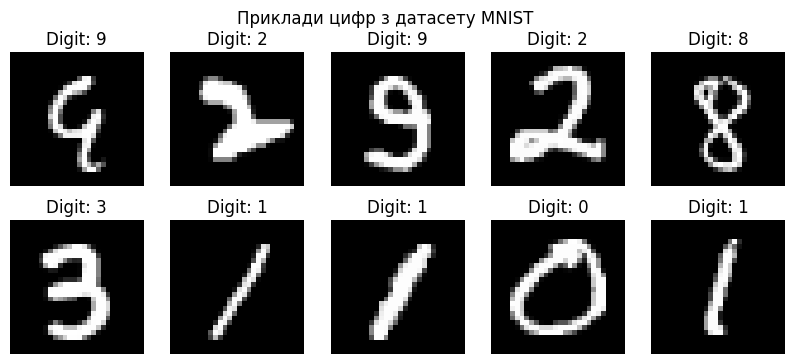

In [6]:
plt.figure(figsize=(10,4))

for i in range(10):

    idx = random.randint(0, len(X)-1)

    plt.subplot(2,5,i+1)
    plt.imshow(X[idx].reshape(28,28), cmap="gray")
    plt.title("Digit: " + str(y[idx]))
    plt.axis("off")

plt.suptitle("Приклади цифр з датасету MNIST")
plt.show()

Застосовуємо PCA, щоб стиснути кожне зображення з 784 пікселів до 3 головних компонент. Перевіряємо, скільки інформації залишилося.

In [7]:
pca = PCA(n_components=3)

X_pca = pca.fit_transform(X)

print("\nНова форма даних після PCA:")
print(X_pca.shape)

print("\nПояснена дисперсія кожної компоненти:")
print(pca.explained_variance_ratio_)

print("Сумарна пояснена дисперсія:")
print(np.sum(pca.explained_variance_ratio_))


Нова форма даних після PCA:
(70000, 3)

Пояснена дисперсія кожної компоненти:
[0.09746116 0.07155445 0.06149531]
Сумарна пояснена дисперсія:
0.2305109149009649


Будуємо хмару точок у 3D-просторі. Кожен колір — це окрема цифра. Дивимось, чи утворилися кластери.

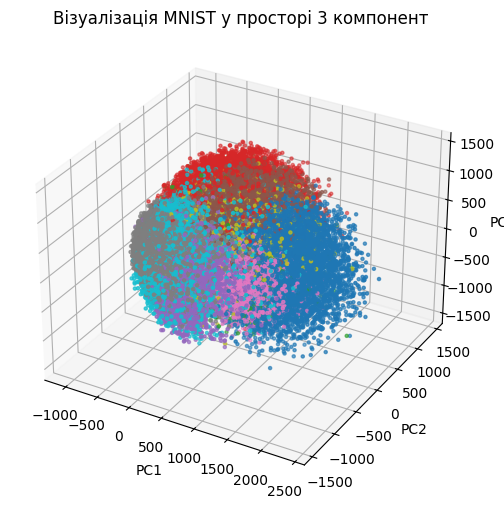

In [8]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_pca[:,0],
    X_pca[:,1],
    X_pca[:,2],
    c=y.astype(int),
    cmap="tab10",
    s=5
)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

plt.title("Візуалізація MNIST у просторі 3 компонент")
plt.show()

Пробуємо відновити зображення з 3-х компонент. Бачимо, що картинка стала розмитою через велику втрату даних.

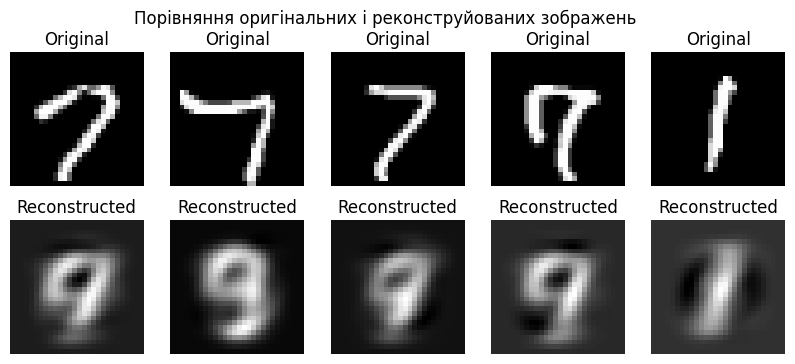

In [9]:
X_reconstructed = pca.inverse_transform(X_pca)

plt.figure(figsize=(10,4))

for i in range(5):

    idx = random.randint(0, len(X)-1)

    plt.subplot(2,5,i+1)
    plt.imshow(X[idx].reshape(28,28), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    plt.subplot(2,5,i+6)
    plt.imshow(X_reconstructed[idx].reshape(28,28), cmap="gray")
    plt.title("Reconstructed")
    plt.axis("off")

plt.suptitle("Порівняння оригінальних і реконструйованих зображень")
plt.show()

Рахуємо помилку реконструкції (MSE) для різної кількості компонент (від 2 до 200), щоб знайти "золоту середину".

In [10]:
components = [2,5,10,20,50,100,200]

mse_list = []
variance_list = []

print("\nОбчислюю MSE для різної кількості компонент...")

for k in components:

    pca_temp = PCA(n_components=k)

    X_k = pca_temp.fit_transform(X)

    X_rec = pca_temp.inverse_transform(X_k)

    mse = mean_squared_error(X, X_rec)

    mse_list.append(mse)

    variance = np.sum(pca_temp.explained_variance_ratio_)
    variance_list.append(variance)


Обчислюю MSE для різної кількості компонент...


Будуємо графіки. Вони показують: чим більше компонент ми беремо, тим менша помилка і тим чіткіше зображення.

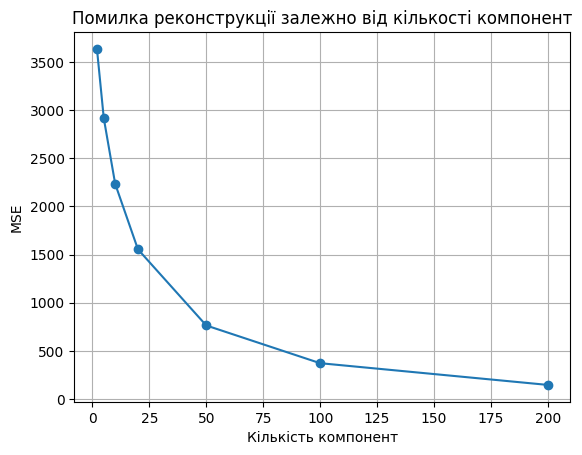

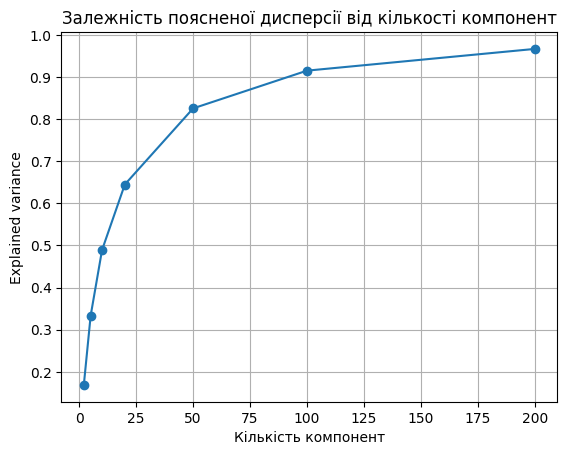

In [11]:
plt.figure()

plt.plot(components, mse_list, marker="o")

plt.xlabel("Кількість компонент")
plt.ylabel("MSE")
plt.title("Помилка реконструкції залежно від кількості компонент")

plt.grid()

plt.show()

plt.figure()

plt.plot(components, variance_list, marker="o")

plt.xlabel("Кількість компонент")
plt.ylabel("Explained variance")

plt.title("Залежність поясненої дисперсії від кількості компонент")

plt.grid()

plt.show()